<a href="https://colab.research.google.com/github/adarsh-sirswal/end-to-end-multiclass-dog-image-classifier/blob/main/dog_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [2]:
# !unzip "drive/MyDrive/Colab Notebooks/dog-vision-project/dog-breed-identification.zip" -d "drive/MyDrive/Colab Notebooks/dog-vision-project/"

# **End-to-end Multi-class Dog Breed Classification**

Building Deep-learning project using Tensorflow 2.0 and Tensorflow Hub.

## 1. Problem

Identification of doog breed using it's image.

## 2. Data

The data is taken from:-
https://www.kaggle.com/c/dog-breed-identification/data

## 3. Evaluation

Evaluation is prediction probabilities for each dog breed in test image.

## 4.Feature

Some information about the data:-
  * Dealing with images (unstructured data).
  * 120 dog breeds (120 different class).
  * 10,000 + training and test data.
  * Training data is labeled and test is not as we have to predict them.

# Getting Workspace ready:-
  * Importing tensorflow
  * Importing tensorflow hub
  * Using GPU (change runtime type)

In [3]:
## Importing tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


In [4]:
## Checking tensorflow Hub version
import tensorflow_hub as hub
print(hub.__version__)

0.16.1


# Getting data ready (changing data into tensors)
  * tensors are multi-dimensional array of numerical values.



In [5]:
## Importing data-labels

labels_csv = pd.read_csv("drive/MyDrive/Colab Notebooks/dog-vision-project/labels.csv")
print(labels_csv.describe())
print(labels_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [6]:
## Images of each breed
distinct_breeds = labels_csv["breed"].value_counts()
len(distinct_breeds)

120

Text(60.0, 83.0, 'Median Value')

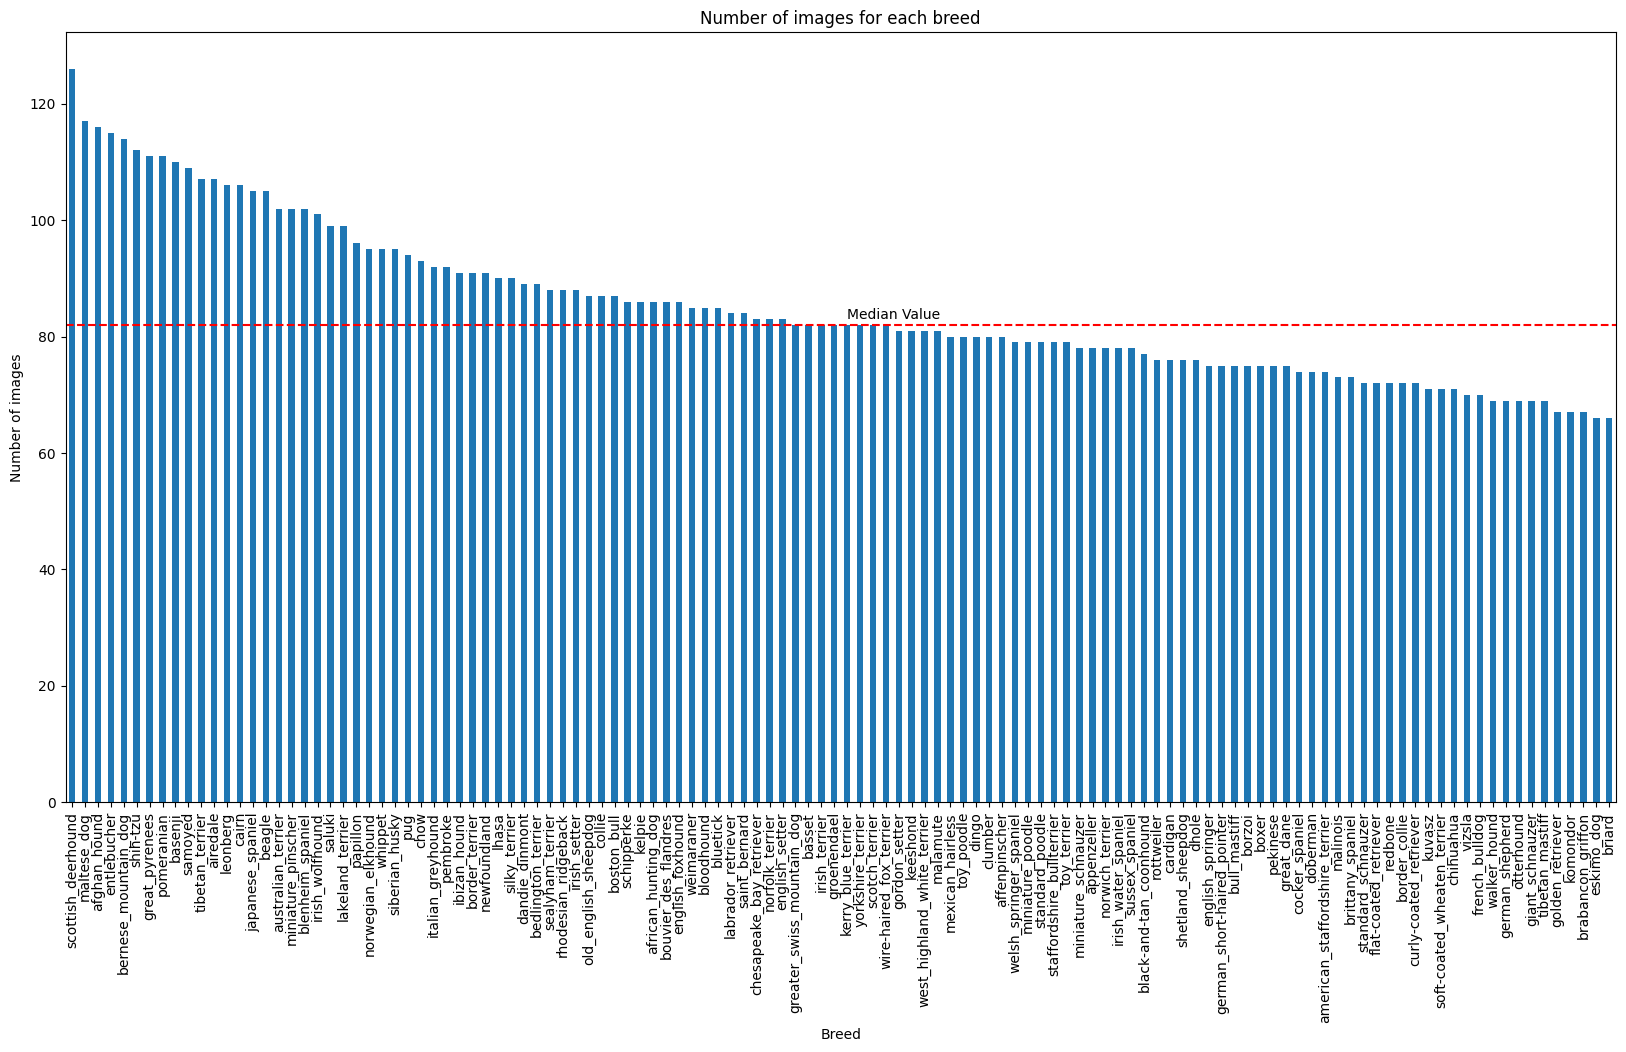

In [7]:
## Plotting
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10));
plt.title("Number of images for each breed");
plt.xlabel("Breed");
plt.ylabel("Number of images");

# Calculate median
median_value = labels_csv.breed.value_counts().median()
# Median line
plt.axhline(
    y=median_value,
    color='red',
    linestyle='--',
    label=f'Median = {median_value}'
)
# Text above median line
plt.text(
    x=len(distinct_breeds)/2,                     # x-position
    y=median_value + 1,      # slightly above line
    s='Median Value',
)

In [8]:
## Median dogs per breed
labels_csv.breed.value_counts().median()

82.0

In [9]:
## Generating File Name
for file_name in labels_csv["id"]:
  print(file_name)

000bec180eb18c7604dcecc8fe0dba07
001513dfcb2ffafc82cccf4d8bbaba97
001cdf01b096e06d78e9e5112d419397
00214f311d5d2247d5dfe4fe24b2303d
0021f9ceb3235effd7fcde7f7538ed62
002211c81b498ef88e1b40b9abf84e1d
00290d3e1fdd27226ba27a8ce248ce85
002a283a315af96eaea0e28e7163b21b
003df8b8a8b05244b1d920bb6cf451f9
0042188c895a2f14ef64a918ed9c7b64
004396df1acd0f1247b740ca2b14616e
0067dc3eab0b3c3ef0439477624d85d6
00693b8bc2470375cc744a6391d397ec
006cc3ddb9dc1bd827479569fcdc52dc
0075dc49dab4024d12fafe67074d8a81
00792e341f3c6eb33663e415d0715370
007b5a16db9d9ff9d7ad39982703e429
007b8a07882822475a4ce6581e70b1f8
007ff9a78eba2aebb558afea3a51c469
008887054b18ba3c7601792b6a453cc3
008b1271ed1addaccf93783b39deab45
008ba178d6dfc1a583617470d19c1673
009509be3ca7cce0ff9e37c8b09b1125
0097c6242c6f3071762d9f85c3ef1b2f
00a338a92e4e7bf543340dc849230e75
00a366d4b4a9bbb6c8a63126697b7656
00a862390341c5be090dd72bd2bc19ef
00b7d114bc5166a629a3cc03d9329120
00ba244566e36e0af3d979320fd3017f
00bee065dcec471f26394855c5c2f3de
00ca187518

In [10]:
## Creating array for path_location for img files.
file_location = ["drive/MyDrive/Colab Notebooks/dog-vision-project/train/" + file_name + ".jpg" for file_name in labels_csv["id"]]
file_location[:10]

['drive/MyDrive/Colab Notebooks/dog-vision-project/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'drive/MyDrive/Colab Notebooks/dog-vision-project/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [11]:
## Checking if no. of filenames are equal to no. of test files
import os
test_len = len(os.listdir("drive/MyDrive/Colab Notebooks/dog-vision-project/train"))
if test_len == len(labels_csv):
  print("Files in testing and no. of locations are equal.")
else:
  print("Not Equal")

Files in testing and no. of locations are equal.


In [12]:
## Creating labels for our dog breeds:-
labels = np.array(labels_csv["breed"])
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [13]:
## Finding unique_label values
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [14]:
## Turning a single label into array of boolens (true, only when unique_breed matches the label)
# Printing the first label name
labels[0]
# Creating boolean array where its name matches the unique breed array
labels[0] == unique_breeds

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [15]:
## Turning every label into boolean array
boolean_labels = [label == np.array(unique_breeds) for label in labels]
# Viewing first 2 boolean arrays
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [16]:
## Turning boolean array into integers
print(labels[0])    # Orignal label
print(np.where(unique_breeds == labels[0]))    # Index where label occurs
print(boolean_labels[0].argmax())
print(boolean_labels[0].astype(int))

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


# Creating a Validation set
Since, kaggle doesn't provide one.

In [17]:
## Setting up X and y variables
X = file_location
y = boolean_labels

Starting off experiment with less samples.

In [18]:
## This slider feature is available in google colab
NUM_IMAGES =  1000 #@param {type:"slider", min:1000, max:10000}

In [19]:
## Splitting data into training and validation set.
from sklearn.model_selection import train_test_split

## Splitting into train and validation set.
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  random_state=42, test_size=0.2)
len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

# Preprocessing images
For preprocessing, we are going to do somethings:-
  * Take image file path as input.
  * Use tensorflow to read the file and save it as `image`.
  * Turn `image` to tensor (jpg).
  * Resize `image` to (224,224).
  * Return modified image.

In [20]:
## Converting image to nparray
from matplotlib.pyplot import imread   ## imread is used to read an image, and convert it into numpy array.
image = imread(file_location[29])
image.shape   ## (height, width, channel (3 for rgb)/ (4 for rgba)).

(375, 500, 3)

array([[[ 10,  11,  15],
        [ 14,  15,  19],
        [ 17,  18,  22],
        ...,
        [ 15,  12,   5],
        [ 23,  20,  13],
        [ 27,  24,  17]],

       [[ 12,  13,  17],
        [ 11,  12,  14],
        [ 10,  11,  15],
        ...,
        [ 22,  19,  14],
        [ 20,  17,  12],
        [ 26,  23,  18]],

       [[ 13,  14,  16],
        [  9,  11,  10],
        [  6,   7,   9],
        ...,
        [ 17,  13,  12],
        [  3,   0,   0],
        [  3,   0,   0]],

       ...,

       [[104,  90,  61],
        [119, 105,  76],
        [143, 126,  98],
        ...,
        [164, 147, 129],
        [160, 143, 125],
        [161, 144, 126]],

       [[111,  97,  68],
        [125, 111,  82],
        [132, 115,  87],
        ...,
        [147, 130, 112],
        [150, 133, 115],
        [154, 137, 119]],

       [[120, 106,  77],
        [147, 133, 104],
        [134, 117,  89],
        ...,
        [130, 113,  95],
        [136, 119, 101],
        [140, 123, 105]]], dtype=uint8)
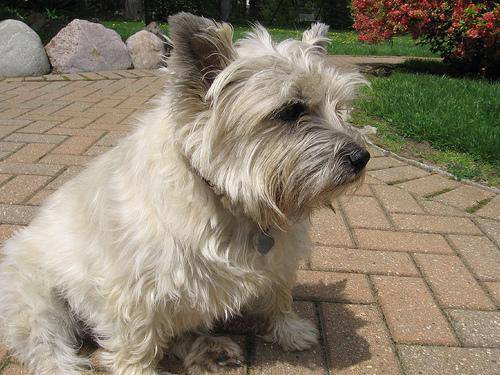

In [21]:
image ## ndarray containing values from 0 to 255.

In [22]:
image.max(), image.min()

(np.uint8(255), np.uint8(0))

# Why is image converted to Tensors for preprocessing?
* GPU Acceleration and Parallel Processing: Tensors allow for efficient parallel computation on GPUs (or TPUs), making it possible to process large batches of images simultaneously rather than sequentially.

* Standardized Format for Neural Networks: Neural networks (like CNNs) are built to process tensors as inputs, performing operations on these numerical structures to learn patterns and predict outputs.

* So, we turn our batches into size of `32`.

* We, convert image into the format of :
      `(label, image)`


In [23]:
IMG_SIZE = 224

def process_image(file_location, img_size=IMG_SIZE):
  '''
        Takes file location and returns them in tensors.
  '''
  ## Reading img file.
  image = tf.io.read_file(file_location)
  ## Turning jpeg into tensor, with 3 colour channels. (r,g,b).
  image = tf.image.decode_jpeg(image, channels=3)
  ## Converting colour channel value from 0-255 to 0-1.
  image = tf.image.convert_image_dtype(image, tf.float32)
  ## Resizing image into desired value (224,224).
  image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

  return image

## Turning data into batches

WHY?
1. Memory Efficiency
2. 2. Faster Training with GPUs

  * GPUs are optimized for parallel computation. Matrix operations become massively faster in batches.

3. TensorFlow Pipelines Are Built Around Batches

In [24]:
def get_image_label(file_location, label):
  '''
      Takes file location and label and returns them in tensors.
  '''
  image = process_image(file_location)
  return image, label

In [25]:
## DEMO of the above.
get_image_label(X[42], tf.constant(y[42]))  ## Used, tf.constant(), to convert boolean labels into tensors.

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117757],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

Since we got a way to turn our data into tuples of `(image, label)`, so now we make a function to turn all our data (X and y) and divide them into batches of 32.